# Exercise 02: Data Visualization for Bias Detection
## Cluster 4 - Pandas and Visualization
**Framework:** NIST AI RMF Measure Function, EU AI Act Annex III

**Case Study:** Recruitment AI

In [2]:
import pandas as pd
import numpy as np

np.random.seed(42)
# Create hiring dataset — 100 applicants
n = 100

data = {
    'gender': ['woman'] * 50 + ['man'] * 50,
    'experience': np.random.randint(1, 15, n),
    'education_score': np.random.randint(60, 100, n),
    'interview_score': np.random.randint(60, 100, n),
}

df = pd.DataFrame(data)
print(df.head(10))
print(f"\nShape: {df.shape}")

  gender  experience  education_score  interview_score
0  woman           7               82               71
1  woman           4               99               98
2  woman          13               80               61
3  woman          11               75               62
4  woman           8               77               96
5  woman          13               83               76
6  woman           5               85               61
7  woman           7               84               61
8  woman          10               88               87
9  woman           3               74               82

Shape: (100, 4)


In [6]:
df['total_score'] = (
    df['experience'] * (1/3) +
    df['education_score'] * (1/3) +
    df['interview_score'] * (1/3)
)

In [10]:
print(df['total_score'].describe())

count    100.000000
mean      56.123333
std        6.153965
min       41.666667
25%       51.666667
50%       55.833333
75%       61.416667
max       67.000000
Name: total_score, dtype: float64


In [11]:
df['hired'] = df['total_score'] >= 60

In [12]:
df.head(10)

,gender,experience,education_score,interview_score,total_score,hired
0,woman,7,82,71,53.333333,False
1,woman,4,99,98,67.000000,True
2,woman,13,80,61,51.333333,False
3,woman,11,75,62,49.333333,False
4,woman,8,77,96,60.333333,True
5,woman,13,83,76,57.333333,False
6,woman,5,85,61,50.333333,False
7,woman,7,84,61,50.666667,False
8,woman,10,88,87,61.666667,True
9,woman,3,74,82,53.000000,False


In [13]:
print(df.groupby('gender')['hired'].value_counts())

gender  hired
man     False    33
        True     17
woman   False    35
        True     15
Name: count, dtype: int64


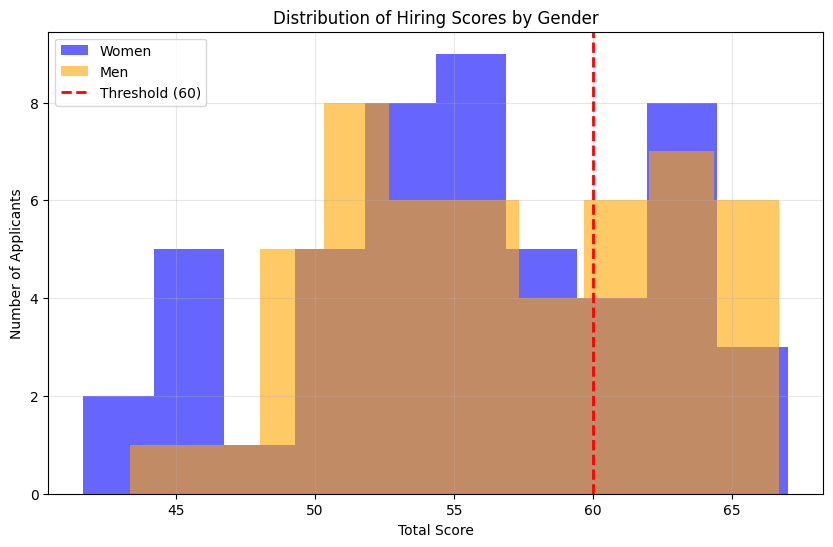

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(df[df['gender'] == 'woman']['total_score'], bins=10, alpha=0.6, label='Women', color='blue')
plt.hist(df[df['gender'] == 'man']['total_score'], bins=10, alpha=0.6, label='Men', color='orange')
plt.axvline(60, color='red', linestyle='--', linewidth=2, label='Threshold (60)')
plt.xlabel('Total Score')
plt.ylabel('Number of Applicants')
plt.title('Distribution of Hiring Scores by Gender')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

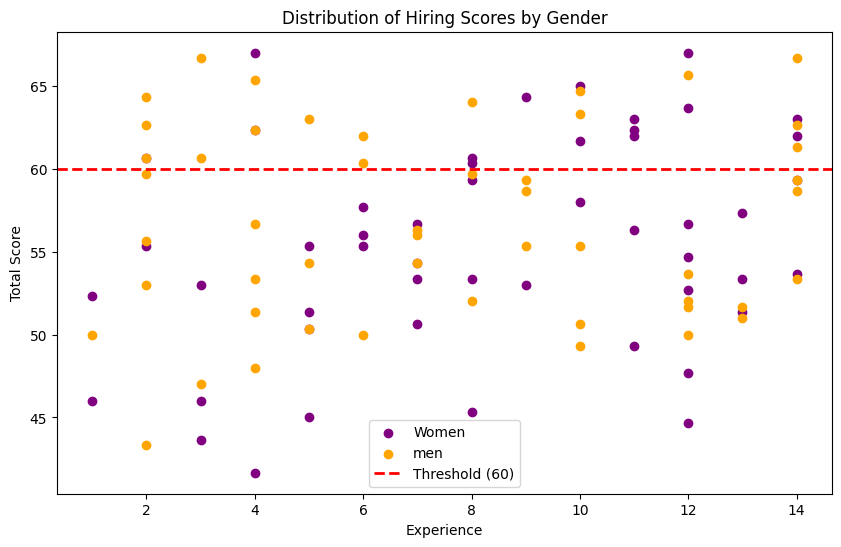

In [29]:
plt.figure(figsize=(10, 6))
plt.scatter(df[df['gender'] == 'woman']['experience'], df[df['gender'] == 'woman']['total_score'], color='purple', label='Women')
plt.scatter(df[df['gender'] == 'man']['experience'], df[df['gender'] == 'man']['total_score'], color='orange', label='men')
plt.axhline(60, color='red', linestyle='--', linewidth=2, label='Threshold (60)')
plt.xlabel('Experience')
plt.ylabel('Total Score')
plt.title('Distribution of Hiring Scores by Gender')
plt.legend()
plt.show()

In [39]:
hiring_rate= df.groupby('gender')['hired'].mean() * 100
print(hiring_rate)

gender
man      34.0
woman    30.0
Name: hired, dtype: float64


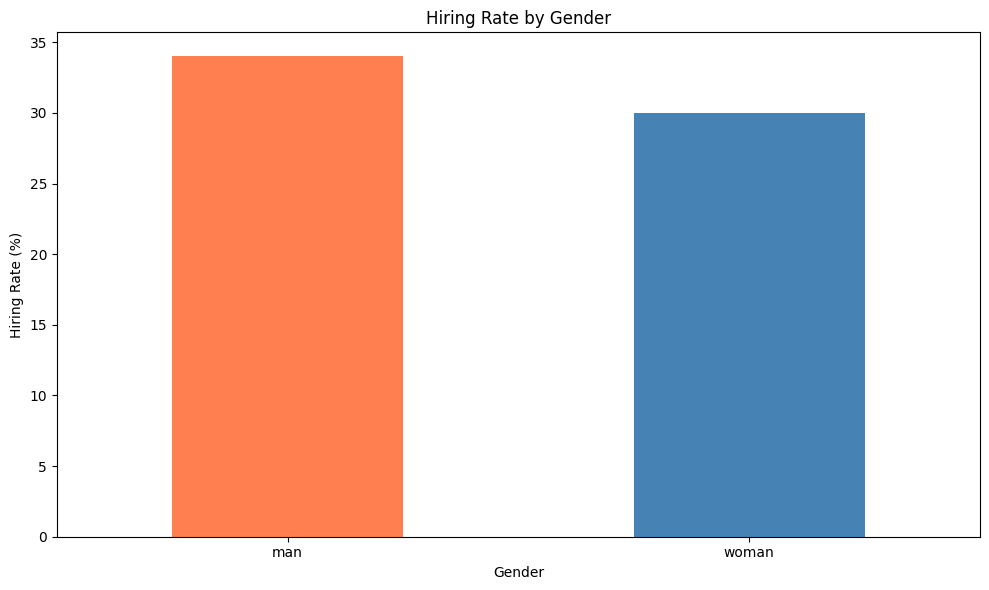

In [40]:
plt.figure(figsize=(10, 6))
hiring_rate.plot(kind='bar', color=['coral', 'steelblue'])
plt.title('Hiring Rate by Gender')
plt.ylabel('Hiring Rate (%)')
plt.xlabel('Gender')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Governance Story** 

The three visualizations together reveal a hidden bias mechanism. The histogram shows women and men have nearly identical score distributions — suggesting fairness. The scatter plot exposes the problem: experience, where women score higher on average, barely moves the total score due to scale mismatch. The bar chart shows the outcome: 34% hiring for men, 30% for women. The gap is small, but the root cause is not different ability — it's a scoring formula that undervalues experience relative to credentials.

**Exercise 02 Reflection** 

Equal weighting of experience, education, and interview scores appears neutral on the surface. However, each component encodes different socioeconomic outcomes. Prioritizing experience advantages applicants without career gaps — disproportionately affecting women and people with health or caregiving constraints. Prioritizing education advantages those with access to higher education. Prioritizing interviews introduces interviewer subjectivity and cultural fit bias. No weighting scheme is truly "fair" — the system must explicitly choose which disadvantaged group it serves and document that choice. The visualization reveals this: identical score distributions across genders mask a structural disadvantage embedded in the formula itself.
